# THỰC HÀNH 02 - OPENCV: LÀM TRƠN ẢNH VÀ PHÁT HIỆN BIÊN

## Thông tin chung

Bài thực hành thuộc môn **Thị Giác Máy Tính Nâng Cao** (*Advanced Computer Vision - K35 - HCMUS*).

- Thành viên nhóm:
  - Nguyễn Trọng Hiếu – 25C11042 (Nhóm trưởng)
  - Trương Lê Bảo Trân – 25C11071
- Giảng viên hướng dẫn: ThS. Nguyễn Mạnh Hùng

## Mục tiêu

Notebook này thực hiện hai nhóm kỹ thuật xử lý ảnh cơ bản bằng OpenCV:

1. **Làm trơn ảnh (Smoothing):** Averaging, Gaussian Blur, Median Blur.
2. **Phát hiện biên ảnh (Edge Detection):** Sobel, Laplacian, Laplacian of Gaussian (LoG), Canny.

In [5]:
import os
from pathlib import Path
from urllib.request import urlretrieve

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Cấu hình thư mục
IMAGE_DIR = Path("images")
OUTPUT_DIR = Path("output")
IMAGE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

IMAGE_PATH = IMAGE_DIR / "Lenna.jpg"
LENNA_URL = "http://www.ess.ic.kanagawa-it.ac.jp/std_img/colorimage/Lenna.jpg"

print(f"Image path : {IMAGE_PATH}")
print(f"Output dir : {OUTPUT_DIR}")


Image path : images/Lenna.jpg
Output dir : output


## 1. Chuẩn bị ảnh đầu vào

Ảnh được đọc bằng OpenCV ở định dạng BGR, sau đó chuyển sang RGB để hiển thị đúng màu bằng Matplotlib. Với các kỹ thuật phát hiện biên, ảnh RGB được chuyển sang ảnh xám (*grayscale*).

In [6]:
if not IMAGE_PATH.exists():
    print(f"Không tìm thấy {IMAGE_PATH}. Đang tải ảnh Lenna từ Internet...")
    try:
        urlretrieve(LENNA_URL, IMAGE_PATH)
    except Exception as exc:
        raise FileNotFoundError(
            "Không tìm thấy images/Lenna.jpg và không thể tải ảnh từ URL. "
            "Hãy kiểm tra kết nối Internet hoặc đặt ảnh Lenna vào thư mục images."
        ) from exc

    if not IMAGE_PATH.exists() or IMAGE_PATH.stat().st_size == 0:
        raise FileNotFoundError(
            "Tải ảnh Lenna không thành công. Hãy đặt ảnh Lenna vào thư mục images trước khi chạy notebook."
        )

# OpenCV đọc ảnh màu theo thứ tự BGR
image_bgr = cv2.imread(str(IMAGE_PATH))
if image_bgr is None:
    raise ValueError("Không thể đọc ảnh đầu vào.")

# Chuyển sang RGB để hiển thị bằng matplotlib
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

print("Kích thước ảnh màu:", image_rgb.shape)
print("Kích thước ảnh xám:", gray.shape)


Kích thước ảnh màu: (150, 150, 3)
Kích thước ảnh xám: (150, 150)


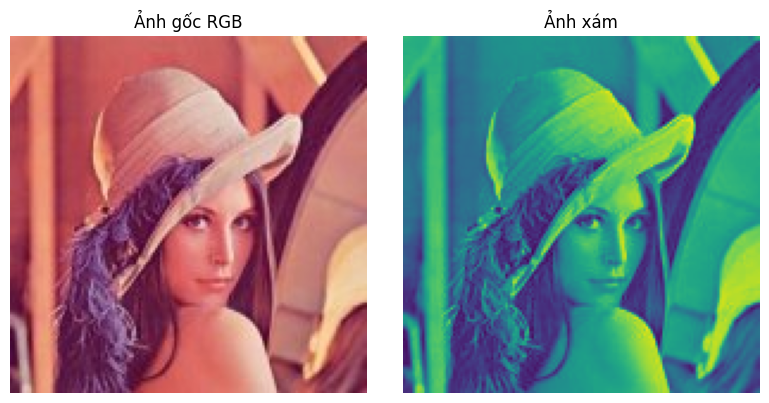

In [7]:
def show_images(images, titles, cmap=None, figsize=(14, 5)):
    """Hiển thị nhiều ảnh trên cùng một hàng."""
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(1, len(images), i)
        plt.imshow(img, cmap=cmap)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


def save_rgb(path, img_rgb):
    """Lưu ảnh RGB ra file bằng OpenCV."""
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(path), img_bgr)


def save_gray(path, img_gray):
    """Lưu ảnh xám ra file."""
    cv2.imwrite(str(path), img_gray)

show_images([image_rgb, gray], ["Ảnh gốc RGB", "Ảnh xám"], figsize=(8, 4))

# 2. Làm trơn ảnh (Smoothing)

Làm trơn ảnh giúp giảm nhiễu và làm mềm vùng chuyển tiếp cường độ. Bài thực hành dùng kernel kích thước `5x5` cho cả ba phương pháp để dễ so sánh.

## 2.1. Averaging Blur

**Averaging** thay mỗi pixel bằng trung bình các pixel lân cận trong kernel. Cách này đơn giản nhưng dễ làm mờ biên ảnh.

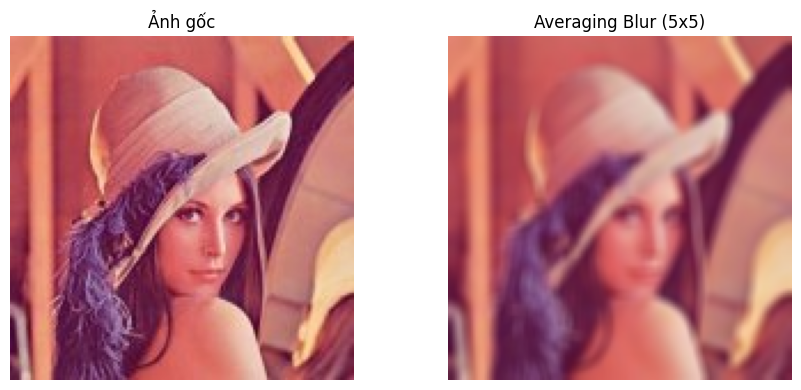

In [8]:
averaging = cv2.blur(image_rgb, (5, 5))
save_rgb(OUTPUT_DIR / "01_averaging_blur.jpg", averaging)

show_images(
    [image_rgb, averaging],
    ["Ảnh gốc", "Averaging Blur (5x5)"],
    figsize=(9, 4)
)

## 2.2. Gaussian Blur

**Gaussian Blur** dùng bộ lọc Gaussian, gán trọng số lớn hơn cho các pixel gần tâm kernel. Phương pháp này thường làm trơn tự nhiên hơn Averaging.

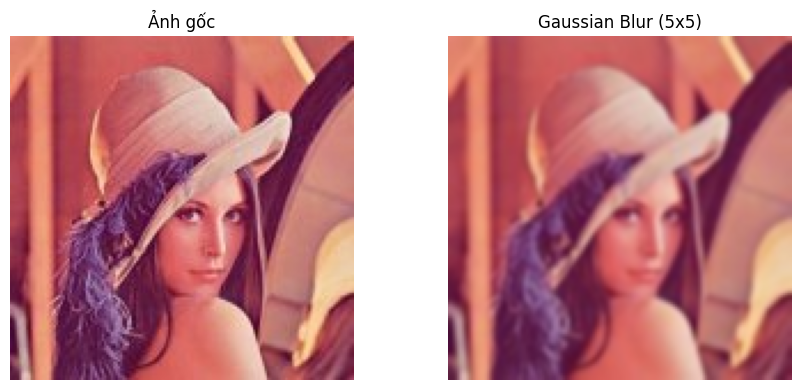

In [9]:
gaussian = cv2.GaussianBlur(image_rgb, (5, 5), sigmaX=0)
save_rgb(OUTPUT_DIR / "02_gaussian_blur.jpg", gaussian)

show_images(
    [image_rgb, gaussian],
    ["Ảnh gốc", "Gaussian Blur (5x5)"],
    figsize=(9, 4)
)

## 2.3. Median Blur

**Median Blur** thay mỗi pixel bằng trung vị của các pixel lân cận. Phương pháp này phù hợp với nhiễu dạng muối tiêu (*salt-and-pepper noise*) và giữ biên tốt hơn trung bình cộng.

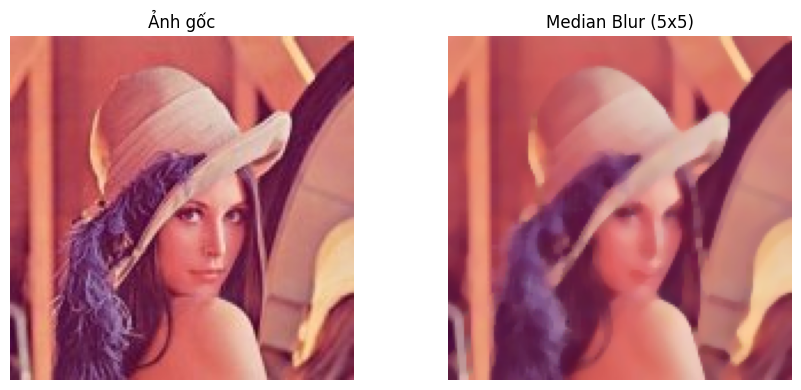

In [10]:
median = cv2.medianBlur(image_rgb, 5)
save_rgb(OUTPUT_DIR / "03_median_blur.jpg", median)

show_images(
    [image_rgb, median],
    ["Ảnh gốc", "Median Blur (5x5)"],
    figsize=(9, 4)
)

## 2.4. So sánh các phương pháp làm trơn

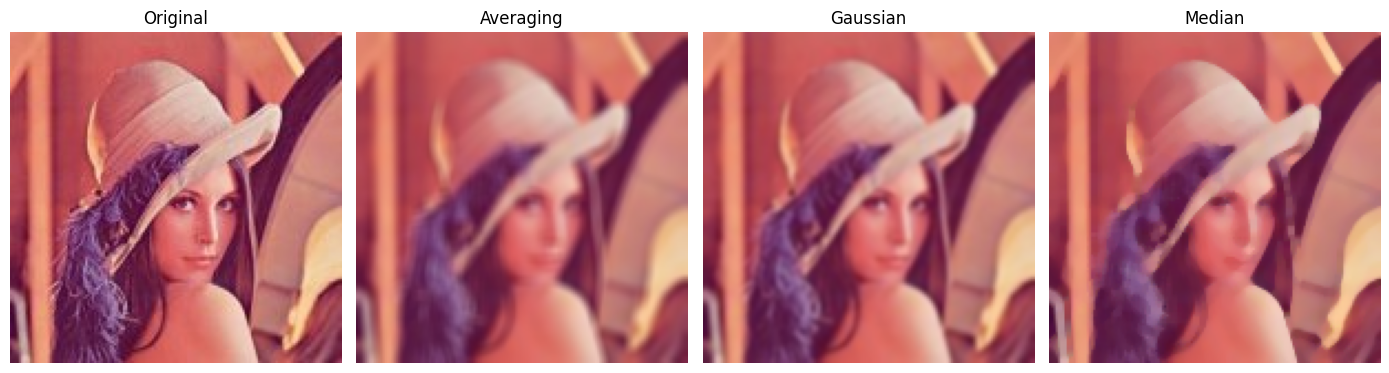

In [11]:
show_images(
    [image_rgb, averaging, gaussian, median],
    ["Original", "Averaging", "Gaussian", "Median"],
    figsize=(14, 4)
)

# 3. Phát hiện biên cạnh (Edge Detection)

Các phương pháp phát hiện biên tìm vùng có sự thay đổi cường độ mạnh trong ảnh. Trước khi phát hiện biên, ảnh được chuyển sang grayscale để giảm độ phức tạp xử lý.

## 3.1. Sobel

**Sobel** ước lượng đạo hàm theo hai hướng `x` và `y`, sau đó kết hợp hai gradient để tạo bản đồ biên.

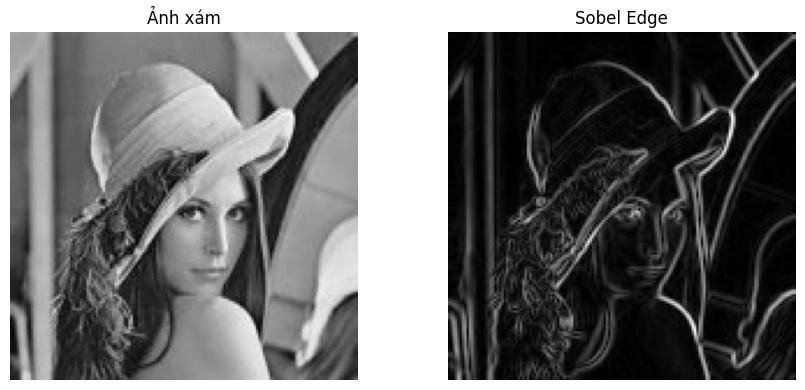

In [12]:
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_magnitude = np.sqrt(sobel_x ** 2 + sobel_y ** 2)
sobel = cv2.normalize(sobel_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

save_gray(OUTPUT_DIR / "04_sobel_edge.jpg", sobel)

show_images(
    [gray, sobel],
    ["Ảnh xám", "Sobel Edge"],
    cmap="gray",
    figsize=(9, 4)
)

## 3.2. Laplacian

**Laplacian** dùng đạo hàm bậc hai để phát hiện vùng thay đổi cường độ nhanh. Phương pháp này nhạy với nhiễu hơn Sobel.

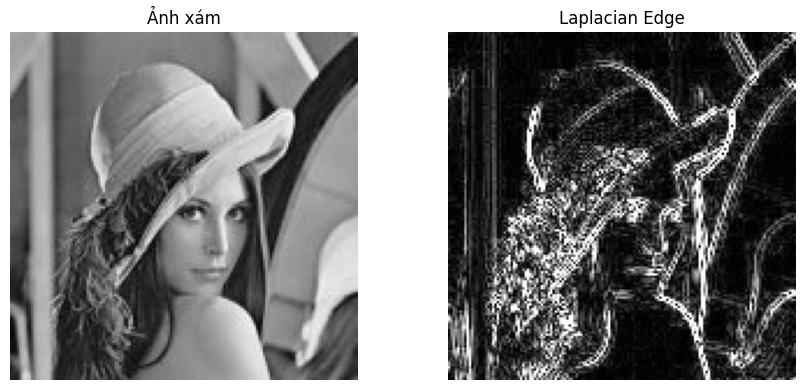

In [13]:
laplacian_64f = cv2.Laplacian(gray, cv2.CV_64F, ksize=3)
laplacian = cv2.convertScaleAbs(laplacian_64f)

save_gray(OUTPUT_DIR / "05_laplacian_edge.jpg", laplacian)

show_images(
    [gray, laplacian],
    ["Ảnh xám", "Laplacian Edge"],
    cmap="gray",
    figsize=(9, 4)
)

## 3.3. Laplacian of Gaussian (LoG)

**LoG** làm trơn ảnh bằng Gaussian trước, sau đó áp dụng Laplacian. Bước Gaussian giúp giảm nhiễu trước khi tính đạo hàm bậc hai.

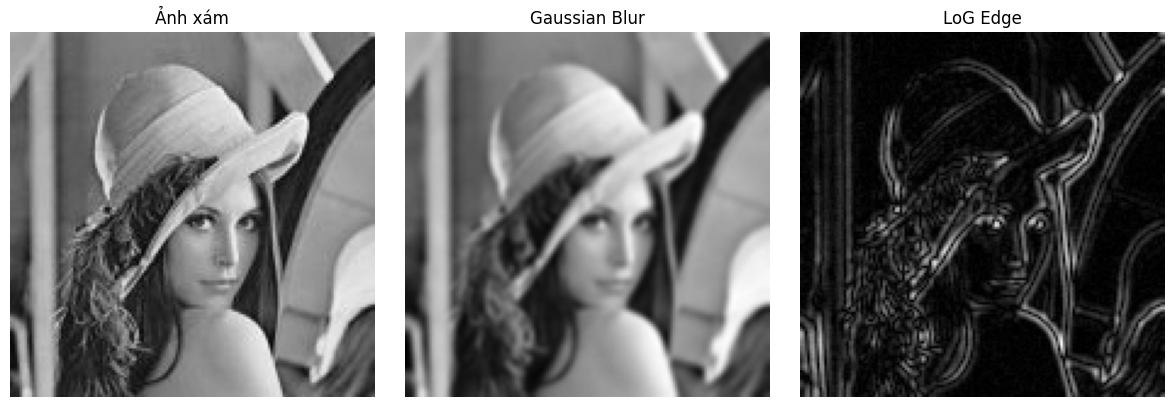

In [14]:
gaussian_gray = cv2.GaussianBlur(gray, (5, 5), sigmaX=0)
log_64f = cv2.Laplacian(gaussian_gray, cv2.CV_64F, ksize=3)
log = cv2.convertScaleAbs(log_64f)

save_gray(OUTPUT_DIR / "06_log_edge.jpg", log)

show_images(
    [gray, gaussian_gray, log],
    ["Ảnh xám", "Gaussian Blur", "LoG Edge"],
    cmap="gray",
    figsize=(12, 4)
)

## 3.4. Canny

**Canny** là phương pháp phát hiện biên nhiều bước, gồm làm trơn, tính gradient, loại bỏ điểm không cực đại và dùng hai ngưỡng để theo dõi biên. Kết quả thường mảnh và rõ hơn các phương pháp đạo hàm đơn giản.

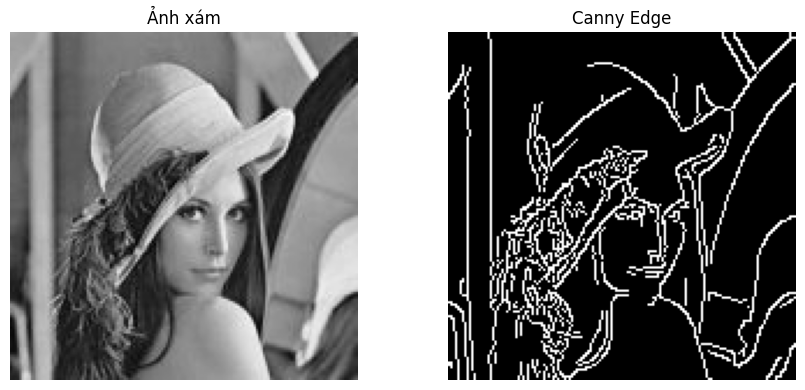

In [15]:
canny = cv2.Canny(gray, threshold1=100, threshold2=200)
save_gray(OUTPUT_DIR / "07_canny_edge.jpg", canny)

show_images(
    [gray, canny],
    ["Ảnh xám", "Canny Edge"],
    cmap="gray",
    figsize=(9, 4)
)

## 3.5. So sánh các phương pháp phát hiện biên

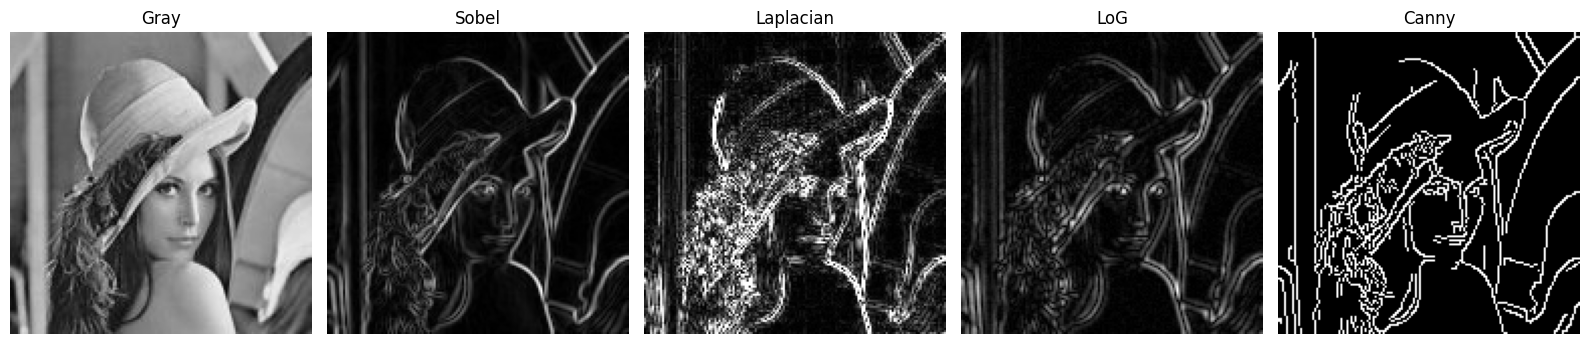

In [16]:
show_images(
    [gray, sobel, laplacian, log, canny],
    ["Gray", "Sobel", "Laplacian", "LoG", "Canny"],
    cmap="gray",
    figsize=(16, 4)
)

# 4. Nhận xét kết quả

| Nhóm kỹ thuật | Phương pháp | Nhận xét ngắn |
|---|---|---|
| Smoothing | Averaging | Làm mờ đều toàn ảnh, đơn giản nhưng dễ làm mất chi tiết biên. |
| Smoothing | Gaussian | Làm trơn tự nhiên hơn nhờ trọng số Gaussian, thường phù hợp trước bước phát hiện biên. |
| Smoothing | Median | Giữ biên tương đối tốt, hiệu quả với nhiễu muối tiêu. |
| Edge Detection | Sobel | Bắt biên theo hướng tốt, kết quả mềm và còn nhiều vùng gradient. |
| Edge Detection | Laplacian | Nhạy với thay đổi cường độ nhưng cũng nhạy với nhiễu. |
| Edge Detection | LoG | Ổn định hơn Laplacian vì có bước làm trơn trước. |
| Edge Detection | Canny | Biên mảnh, rõ và dễ quan sát nhất trong các phương pháp được thử nghiệm. |

## Kết luận

Các kỹ thuật smoothing giúp giảm nhiễu và cải thiện chất lượng tiền xử lý. Trong nhóm phát hiện biên, Canny thường cho kết quả trực quan nhất, trong khi Sobel, Laplacian và LoG giúp minh họa rõ vai trò của đạo hàm trong xử lý ảnh.

# 5. Danh sách file kết quả

In [17]:
for path in sorted(OUTPUT_DIR.glob("*.jpg")):
    print(path)

output/01_averaging_blur.jpg
output/02_gaussian_blur.jpg
output/03_median_blur.jpg
output/04_sobel_edge.jpg
output/05_laplacian_edge.jpg
output/06_log_edge.jpg
output/07_canny_edge.jpg
